# IQL Q-Ensemble Extension
**CMPE 260 — Group 6 | Uday Arora (019098404)**

This notebook implements Implicit Q-Learning (IQL) from scratch using modern JAX/Flax,
then extends it with a Q-Ensemble (TripleCritic) and compares both on hopper-medium-v2.

**Hypothesis:** 3 Q-networks taking the min produces more conservative value estimates,
improving robustness under distribution shift.

## Cell 1 — Install Dependencies

In [1]:
!pip install -q "jax[cuda12_pip]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
!pip install -q flax optax
!pip install -q tensorflow-probability[jax]
!pip install -q mujoco "gymnasium[mujoco]"
!pip install -q h5py tqdm matplotlib pandas
print('Done')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 27.5 MB/s eta 0:00:00
Done


## Cell 2 — Verify JAX

In [2]:
import jax
import jax.numpy as jnp
import flax
import optax
print('JAX:', jax.__version__)
print('Flax:', flax.__version__)
print('Optax:', optax.__version__)
print('Devices:', jax.devices())

JAX: 0.7.2
Flax: 0.11.2
Optax: 0.2.8
Devices: [CudaDevice(id=0)]


## Cell 3 — Clone Repo

In [3]:
import os, sys
if not os.path.exists('/content/iql-robustness-analysis'):
    !git clone https://github.com/shloakk/iql-robustness-analysis /content/iql-robustness-analysis
%cd /content/iql-robustness-analysis
!git checkout -B uday/q-ensemble
sys.path.insert(0, '/content/iql-robustness-analysis')
print('Repo ready')

Cloning into '/content/iql-robustness-analysis'...
remote: Enumerating objects: 237, done.
remote: Counting objects: 100% (237/237), done.
remote: Compressing objects: 100% (165/165), done.
remote: Total 237 (delta 123), reused 177 (delta 70), pack-reused 0 (from 0)
Receiving objects: 100% (237/237), 3.07 MiB | 20.54 MiB/s, done.
Resolving deltas: 100% (123/123), done.
/content/iql-robustness-analysis
Switched to a new branch 'uday/q-ensemble'
Repo ready


## Cell 4 — Download and Load Dataset

In [4]:
import h5py
import numpy as np

!wget -q -O hopper-medium-v2.hdf5 "https://rail.eecs.berkeley.edu/datasets/offline_rl/gym_mujoco_v2/hopper_medium-v2.hdf5"

with h5py.File('hopper-medium-v2.hdf5', 'r') as f:
    observations      = f['observations'][:].astype(np.float32)
    next_observations = f['next_observations'][:].astype(np.float32)
    actions           = f['actions'][:].astype(np.float32)
    rewards           = f['rewards'][:].astype(np.float32)
    terminals         = f['terminals'][:].astype(np.float32)

masks = 1.0 - terminals
eps   = 1e-5
actions = np.clip(actions, -(1-eps), (1-eps))

print(f'Transitions: {len(observations):,}')
print(f'obs shape:   {observations.shape}')
print(f'act shape:   {actions.shape}')
print(f'reward range: [{rewards.min():.2f}, {rewards.max():.2f}]')

Transitions: 1,000,000
obs shape:   (1000000, 11)
act shape:   (1000000, 3)
reward range: [0.55, 5.94]


## Cell 5 — Normalize Rewards

In [5]:
# Compute episode returns to normalize rewards (same as original IQL paper)
ep_returns, ep_ret = [], 0.0
for r, t in zip(rewards, terminals):
    ep_ret += r
    if t:
        ep_returns.append(ep_ret)
        ep_ret = 0.0

min_ret, max_ret = min(ep_returns), max(ep_returns)
rewards_norm = rewards / (max_ret - min_ret) * 1000.0

# Hopper-medium-v2 d4rl normalization constants
RANDOM_SCORE = 20.272305
EXPERT_SCORE = 3234.3

def normalized_score(raw):
    return (raw - RANDOM_SCORE) / (EXPERT_SCORE - RANDOM_SCORE) * 100.0

print(f'Episode returns — min: {min_ret:.1f}, max: {max_ret:.1f}, count: {len(ep_returns)}')
print(f'Normalized reward range: [{rewards_norm.min():.3f}, {rewards_norm.max():.3f}]')

Episode returns — min: 315.9, max: 4565.5, count: 2185
Normalized reward range: [0.129, 1.399]


## Cell 6 — Dataset Sampler

In [6]:
import collections

Batch = collections.namedtuple(
    'Batch', ['observations', 'actions', 'rewards', 'masks', 'next_observations'])

class D4RLDataset:
    def __init__(self, obs, acts, rews, masks, next_obs):
        self.observations      = obs
        self.actions           = acts
        self.rewards           = rews
        self.masks             = masks
        self.next_observations = next_obs
        self.size = len(obs)

    def sample(self, batch_size):
        idx = np.random.randint(self.size, size=batch_size)
        return Batch(
            observations=self.observations[idx],
            actions=self.actions[idx],
            rewards=self.rewards[idx],
            masks=self.masks[idx],
            next_observations=self.next_observations[idx]
        )

dataset = D4RLDataset(observations, actions, rewards_norm, masks, next_observations)
print(f'Dataset ready — {dataset.size:,} transitions')
b = dataset.sample(4)
print(f'Sample batch obs shape: {b.observations.shape}')

Dataset ready — 1,000,000 transitions
Sample batch obs shape: (4, 11)


## Cell 7 — IQL Networks (Modern Flax, No Legacy APIs)

In [7]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
from typing import Sequence, Callable, Optional, Any, Tuple


# ── MLP ──────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    hidden_dims: Sequence[int]
    activations: Callable = nn.relu
    activate_final: bool = False

    @nn.compact
    def __call__(self, x):
        for i, size in enumerate(self.hidden_dims):
            x = nn.Dense(size)(x)
            if i + 1 < len(self.hidden_dims) or self.activate_final:
                x = self.activations(x)
        return x


# ── Value Network ─────────────────────────────────────────────────────────
class ValueNet(nn.Module):
    hidden_dims: Sequence[int]

    @nn.compact
    def __call__(self, obs):
        return jnp.squeeze(MLP((*self.hidden_dims, 1))(obs), -1)


# ── Single Critic ─────────────────────────────────────────────────────────
class SingleCritic(nn.Module):
    hidden_dims: Sequence[int]

    @nn.compact
    def __call__(self, obs, act):
        x = jnp.concatenate([obs, act], -1)
        return jnp.squeeze(MLP((*self.hidden_dims, 1))(x), -1)


# ── DoubleCritic (baseline IQL) ───────────────────────────────────────────
class DoubleCritic(nn.Module):
    hidden_dims: Sequence[int]

    @nn.compact
    def __call__(self, obs, act):
        q1 = SingleCritic(self.hidden_dims)(obs, act)
        q2 = SingleCritic(self.hidden_dims)(obs, act)
        return q1, q2


# ── TripleCritic (Q-ensemble extension) ───────────────────────────────────
class TripleCritic(nn.Module):
    """Q-Ensemble with 3 critics — more conservative value estimates."""
    hidden_dims: Sequence[int]

    @nn.compact
    def __call__(self, obs, act):
        q1 = SingleCritic(self.hidden_dims)(obs, act)
        q2 = SingleCritic(self.hidden_dims)(obs, act)
        q3 = SingleCritic(self.hidden_dims)(obs, act)
        return q1, q2, q3


# ── Actor (Gaussian policy) ───────────────────────────────────────────────
class Actor(nn.Module):
    hidden_dims: Sequence[int]
    action_dim: int
    log_std_min: float = -5.0
    log_std_max: float = 2.0

    @nn.compact
    def __call__(self, obs):
        x    = MLP(self.hidden_dims, activate_final=True)(obs)
        mean = nn.Dense(self.action_dim)(x)
        mean = nn.tanh(mean)
        log_std = self.param('log_std', nn.initializers.zeros, (self.action_dim,))
        log_std = jnp.clip(log_std, self.log_std_min, self.log_std_max)
        return mean, jnp.exp(log_std)


print('Networks defined successfully')

Networks defined successfully


## Cell 8 — IQL Training State and Update Functions

In [8]:
from flax.training import train_state
import functools


# ── Train State ───────────────────────────────────────────────────────────
class TrainState(train_state.TrainState):
    """Standard Flax train state with params and optimizer."""
    pass


def create_train_state(model, dummy_inputs, lr):
    params = model.init(jax.random.PRNGKey(0), *dummy_inputs)['params']
    tx = optax.adam(lr)
    return TrainState.create(apply_fn=model.apply, params=params, tx=tx)


# ── Expectile Loss ────────────────────────────────────────────────────────
def expectile_loss(diff, expectile=0.7):
    weight = jnp.where(diff > 0, expectile, 1 - expectile)
    return (weight * diff ** 2).mean()


# ── Value Update ──────────────────────────────────────────────────────────
@functools.partial(jax.jit, static_argnames=('use_ensemble',))
def update_value(value_state, critic_state, batch, expectile, use_ensemble):
    if use_ensemble:
        q1, q2, q3 = critic_state.apply_fn({'params': critic_state.params},
                                            batch.observations, batch.actions)
        q = jnp.minimum(jnp.minimum(q1, q2), q3)
    else:
        q1, q2 = critic_state.apply_fn({'params': critic_state.params},
                                        batch.observations, batch.actions)
        q = jnp.minimum(q1, q2)

    def loss_fn(params):
        v = value_state.apply_fn({'params': params}, batch.observations)
        return expectile_loss(q - v, expectile), v.mean()

    (loss, v_mean), grads = jax.value_and_grad(loss_fn, has_aux=True)(value_state.params)
    return value_state.apply_gradients(grads=grads), loss, v_mean


# ── Critic Update ─────────────────────────────────────────────────────────
@functools.partial(jax.jit, static_argnames=('use_ensemble',))
def update_critic(critic_state, target_value_state, batch, discount, use_ensemble):
    next_v = target_value_state.apply_fn({'params': target_value_state.params},
                                          batch.next_observations)
    target_q = batch.rewards + discount * batch.masks * next_v

    def loss_fn(params):
        if use_ensemble:
            q1, q2, q3 = critic_state.apply_fn({'params': params},
                                                batch.observations, batch.actions)
            loss = ((q1-target_q)**2 + (q2-target_q)**2 + (q3-target_q)**2).mean()
            return loss, (q1.mean(), q2.mean())
        else:
            q1, q2 = critic_state.apply_fn({'params': params},
                                            batch.observations, batch.actions)
            loss = ((q1-target_q)**2 + (q2-target_q)**2).mean()
            return loss, (q1.mean(), q2.mean())

    (loss, q_means), grads = jax.value_and_grad(loss_fn, has_aux=True)(critic_state.params)
    return critic_state.apply_gradients(grads=grads), loss


# ── Actor Update ──────────────────────────────────────────────────────────
@functools.partial(jax.jit, static_argnames=('use_ensemble',))
def update_actor(actor_state, critic_state, value_state, batch, temperature, use_ensemble):
    v = value_state.apply_fn({'params': value_state.params}, batch.observations)

    if use_ensemble:
        q1, q2, q3 = critic_state.apply_fn({'params': critic_state.params},
                                            batch.observations, batch.actions)
        q = jnp.minimum(jnp.minimum(q1, q2), q3)
    else:
        q1, q2 = critic_state.apply_fn({'params': critic_state.params},
                                        batch.observations, batch.actions)
        q = jnp.minimum(q1, q2)

    adv     = q - v
    weights = jnp.minimum(jnp.exp(adv * temperature), 100.0)

    def loss_fn(params):
        mean, std = actor_state.apply_fn({'params': params}, batch.observations)
        # Gaussian log prob
        log_prob = -0.5 * (((batch.actions - mean) / std) ** 2
                           + 2 * jnp.log(std)
                           + jnp.log(2 * jnp.pi))
        log_prob = log_prob.sum(-1)
        return -(weights * log_prob).mean()

    loss, grads = jax.value_and_grad(loss_fn)(actor_state.params)
    return actor_state.apply_gradients(grads=grads), loss


# ── Soft Target Update ────────────────────────────────────────────────────
@jax.jit
def soft_update(source_params, target_params, tau=0.005):
    return jax.tree_util.tree_map(
        lambda s, t: tau * s + (1 - tau) * t,
        source_params, target_params)


print('Update functions defined')

Update functions defined


## Cell 9 — Evaluation Function

In [9]:
import gymnasium as gym
import numpy as np

def evaluate(actor_state, env=None, env_name='Hopper-v4', num_episodes=10):
    # if a custom shifted env is passed use it, otherwise create default
    if env is None:
        env = gym.make(env_name)
        close_after = True
    else:
        close_after = False

    returns = []
    for _ in range(num_episodes):
        obs, _ = env.reset()
        done, ep_return = False, 0.0
        while not done:
            obs_j = jnp.array(obs[np.newaxis], dtype=jnp.float32)
            mean, _ = actor_state.apply_fn({'params': actor_state.params}, obs_j)
            action = np.clip(np.array(mean[0]), -1, 1)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_return += reward
        returns.append(ep_return)

    if close_after:
        env.close()

    return float(np.mean(returns))

print('Evaluation function ready')

Evaluation function ready


## Cell 10 — Initialize Agents

In [10]:
import gymnasium as gym

env      = gym.make('Hopper-v4')
obs_dim  = env.observation_space.shape[0]
act_dim  = env.action_space.shape[0]
env.close()

HIDDEN   = (256, 256)
LR       = 3e-4
dummy_obs = jnp.zeros((1, obs_dim))
dummy_act = jnp.zeros((1, act_dim))

# ── Baseline IQL (DoubleCritic) ───────────────────────────────────────────
baseline_actor_state  = create_train_state(Actor(HIDDEN, act_dim), [dummy_obs], LR)
baseline_critic_state = create_train_state(DoubleCritic(HIDDEN), [dummy_obs, dummy_act], LR)
baseline_value_state  = create_train_state(ValueNet(HIDDEN), [dummy_obs], LR)
baseline_target_value_params = baseline_value_state.params

# ── Q-Ensemble IQL (TripleCritic) ─────────────────────────────────────────
ensemble_actor_state  = create_train_state(Actor(HIDDEN, act_dim), [dummy_obs], LR)
ensemble_critic_state = create_train_state(TripleCritic(HIDDEN), [dummy_obs, dummy_act], LR)
ensemble_value_state  = create_train_state(ValueNet(HIDDEN), [dummy_obs], LR)
ensemble_target_value_params = ensemble_value_state.params

print(f'obs_dim={obs_dim}, act_dim={act_dim}')
print('Both agents initialized successfully')

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


obs_dim=11, act_dim=3
Both agents initialized successfully


## Cell 11 — Training Loop

In [11]:
import tqdm

def train_iql(dataset, actor_state, critic_state, value_state, target_value_params,
              use_ensemble=False, max_steps=300000, eval_interval=50000,
              eval_episodes=10, batch_size=256,
              expectile=0.7, temperature=3.0, discount=0.99, tau=0.005):

    label = 'Q-Ensemble (TripleCritic)' if use_ensemble else 'Baseline IQL (DoubleCritic)'
    print(f"\n{'='*50}\nTraining: {label}\n{'='*50}")

    log = []

    for i in tqdm.tqdm(range(1, max_steps + 1), smoothing=0.1):
        batch = dataset.sample(batch_size)

        # Convert to jax arrays
        jbatch = Batch(
            observations=jnp.array(batch.observations),
            actions=jnp.array(batch.actions),
            rewards=jnp.array(batch.rewards),
            masks=jnp.array(batch.masks),
            next_observations=jnp.array(batch.next_observations)
        )

        # Build a temp value state with target params for bootstrapping
        target_value_state = value_state.replace(params=target_value_params)

        value_state, v_loss, v_mean = update_value(
            value_state, critic_state, jbatch, expectile, use_ensemble)

        critic_state, c_loss = update_critic(
            critic_state, target_value_state, jbatch, discount, use_ensemble)

        actor_state, a_loss = update_actor(
            actor_state, critic_state, value_state, jbatch, temperature, use_ensemble)

        # Soft update target value params
        target_value_params = soft_update(value_state.params, target_value_params, tau)

        if i % eval_interval == 0:
            raw_return  = evaluate(actor_state, num_episodes=eval_episodes)
            norm        = normalized_score(raw_return)
            log.append({'step': i, 'raw_return': raw_return, 'normalized_score': norm})
            print(f"Step {i:>7,} | Raw: {raw_return:>7.1f} | Norm Score: {norm:.2f}")

    return actor_state, critic_state, value_state, target_value_params, log

print('Training loop ready')

Training loop ready


## Cell 12 — Run Baseline IQL

In [12]:
(baseline_actor_state, baseline_critic_state,
 baseline_value_state, baseline_target_value_params,
 baseline_log) = train_iql(
    dataset=dataset,
    actor_state=baseline_actor_state,
    critic_state=baseline_critic_state,
    value_state=baseline_value_state,
    target_value_params=baseline_target_value_params,
    use_ensemble=False,
    max_steps=300000,
    eval_interval=50000
)


Training: Baseline IQL (DoubleCritic)


 17%|█▋        | 50026/300000 [03:30<9:57:29,  6.97it/s] 

Step  50,000 | Raw:  1291.7 | Norm Score: 39.56


 33%|███▎      | 100033/300000 [07:04<9:35:36,  5.79it/s] 

Step 100,000 | Raw:  1454.3 | Norm Score: 44.62


...

Step 200,000 | Raw:  2003.3 | Norm Score: 61.70


 83%|████████▎ | 250028/300000 [18:57<2:59:54,  4.63it/s]

Step 250,000 | Raw:  1932.2 | Norm Score: 59.49


100%|██████████| 300000/300000 [22:49<00:00, 219.01it/s]

Step 300,000 | Raw:  1919.3 | Norm Score: 59.09


## Cell 13 — Run Q-Ensemble IQL

In [13]:
(ensemble_actor_state, ensemble_critic_state,
 ensemble_value_state, ensemble_target_value_params,
 ensemble_log) = train_iql(
    dataset=dataset,
    actor_state=ensemble_actor_state,
    critic_state=ensemble_critic_state,
    value_state=ensemble_value_state,
    target_value_params=ensemble_target_value_params,
    use_ensemble=True,
    max_steps=300000,
    eval_interval=50000
)


Training: Q-Ensemble (TripleCritic)


 17%|█▋        | 50026/300000 [03:30<8:34:17,  8.10it/s]

Step  50,000 | Raw:   989.6 | Norm Score: 30.16


 33%|███▎      | 100031/300000 [07:34<13:01:20,  4.27it/s]

Step 100,000 | Raw:  2009.6 | Norm Score: 61.90


...

Step 200,000 | Raw:  1811.4 | Norm Score: 55.73


 83%|████████▎ | 250028/300000 [19:19<2:36:14,  5.33it/s]

Step 250,000 | Raw:  1496.1 | Norm Score: 45.92


100%|██████████| 300000/300000 [23:07<00:00, 216.26it/s]

Step 300,000 | Raw:  1499.1 | Norm Score: 46.01


## Cell 14 — Results Table and Plot

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df_b = pd.DataFrame(baseline_log)
df_e = pd.DataFrame(ensemble_log)

print('Baseline IQL — hopper-medium-v2')
print(df_b.to_string(index=False))
print('\nQ-Ensemble IQL — hopper-medium-v2')
print(df_e.to_string(index=False))

b_final = df_b['normalized_score'].iloc[-1]
e_final = df_e['normalized_score'].iloc[-1]
print(f'\nBaseline final:   {b_final:.2f}')
print(f'Q-Ensemble final: {e_final:.2f}')
print(f'Difference:       {e_final - b_final:+.2f}')

Baseline IQL — hopper-medium-v2
  step  raw_return  normalized_score
 50000 1291.702398         39.558778
100000 1454.288615         44.617422
150000 2155.183664         66.424797
200000 2003.289805         61.698831
250000 1932.227592         59.487829
300000 1919.342234         59.086919

Q-Ensemble IQL — hopper-medium-v2
  step  raw_return  normalized_score
 50000  989.596720         30.159181
100000 2009.624473         61.895925
150000 1866.438415         57.440890
200000 1811.414564         55.728899
250000 1496.128207         45.919203
300000 1499.110495         46.011993

Baseline final:   59.09
Q-Ensemble final: 46.01
Difference:       -13.07


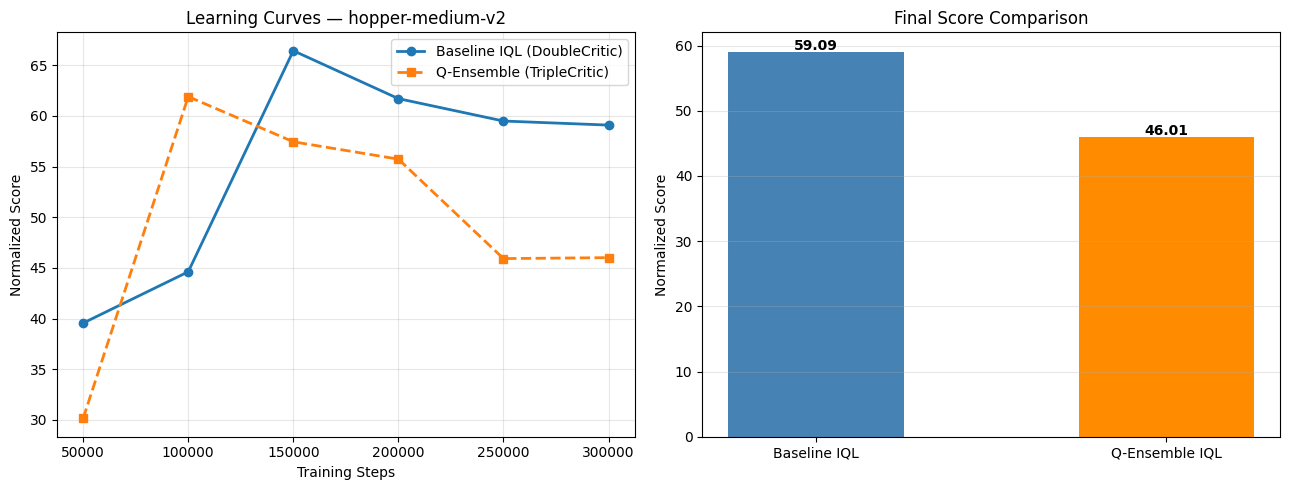

Plot saved


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(df_b['step'], df_b['normalized_score'],
             label='Baseline IQL (DoubleCritic)', marker='o', linewidth=2)
axes[0].plot(df_e['step'], df_e['normalized_score'],
             label='Q-Ensemble (TripleCritic)', marker='s', linewidth=2, linestyle='--')
axes[0].set_xlabel('Training Steps')
axes[0].set_ylabel('Normalized Score')
axes[0].set_title('Learning Curves — hopper-medium-v2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

bars = axes[1].bar(['Baseline IQL', 'Q-Ensemble IQL'],
                    [b_final, e_final],
                    color=['steelblue', 'darkorange'], width=0.5)
axes[1].set_ylabel('Normalized Score')
axes[1].set_title('Final Score Comparison')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, [b_final, e_final]):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150)
plt.show()
print('Plot saved')

## Cell 15 — Save CSVs

In [16]:
df_b.to_csv('results_baseline_iql.csv', index=False)
df_e.to_csv('results_ensemble_iql.csv', index=False)
print('CSVs saved')

CSVs saved


## Cell 16 — Shift Evaluation Loop

In [17]:
import gymnasium as gym
import numpy as np

def evaluate_under_gravity_shift(actor_state, gravity_scale, env_name='Hopper-v4', num_episodes=10):
    env = gym.make(env_name)
    # modify gravity - default hopper gravity is -9.81
    env.unwrapped.model.opt.gravity[2] = -9.81 * gravity_scale

    returns = []
    for _ in range(num_episodes):
        obs, _ = env.reset()
        done, ep_return = False, 0.0
        while not done:
            obs_j = jnp.array(obs[np.newaxis], dtype=jnp.float32)
            mean, _ = actor_state.apply_fn({'params': actor_state.params}, obs_j)
            action = np.clip(np.array(mean[0]), -1, 1)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_return += reward
        returns.append(ep_return)

    env.close()
    return float(np.mean(returns))

# Test it works first
score = evaluate_under_gravity_shift(baseline_actor_state, gravity_scale=1.0)
print(f'Baseline at normal gravity: {normalized_score(score):.2f}')

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Baseline at normal gravity: 52.76


## Cell 17 — Full Grid Run

In [18]:
gravity_scales = [0.5, 1.0, 1.5, 2.0]
results = []

for scale in gravity_scales:
    baseline_score = evaluate_under_gravity_shift(baseline_actor_state, gravity_scale=scale)
    ensemble_score = evaluate_under_gravity_shift(ensemble_actor_state, gravity_scale=scale)

    baseline_norm = normalized_score(baseline_score)
    ensemble_norm = normalized_score(ensemble_score)

    results.append({
        'gravity_scale': scale,
        'baseline_score': baseline_norm,
        'ensemble_score': ensemble_norm,
        'baseline_drop': normalized_score(evaluate_under_gravity_shift(baseline_actor_state, gravity_scale=1.0)) - baseline_norm,
        'ensemble_drop': normalized_score(evaluate_under_gravity_shift(ensemble_actor_state, gravity_scale=1.0)) - ensemble_norm
    })

    print(f'Gravity {scale}x | Baseline: {baseline_norm:.2f} | Q-Ensemble: {ensemble_norm:.2f}')

df_gravity = pd.DataFrame(results)
print('\nFull Results:')
print(df_gravity.to_string(index=False))

Gravity 0.5x | Baseline: 9.45 | Q-Ensemble: 12.18
Gravity 1.0x | Baseline: 57.66 | Q-Ensemble: 43.84
Gravity 1.5x | Baseline: 22.85 | Q-Ensemble: 24.23
Gravity 2.0x | Baseline: 10.92 | Q-Ensemble: 11.81

Full Results:
 gravity_scale  baseline_score  ensemble_score  baseline_drop  ensemble_drop
           0.5        9.454070       12.177846      44.809044      32.584788
           1.0       57.656716       43.842893       8.765072       2.053545
           1.5       22.846086       24.231338      40.056973      21.796732
           2.0       10.918866       11.811474      50.770594      33.372778


## Cell 18 — Observation Noise Experiment

In [19]:
def evaluate_under_obs_noise(actor_state, noise_std, env_name='Hopper-v4', num_episodes=10):
    env = gym.make(env_name)

    returns = []
    for _ in range(num_episodes):
        obs, _ = env.reset()
        done, ep_return = False, 0.0
        while not done:
            # add gaussian noise to observation
            noisy_obs = obs + np.random.normal(0, noise_std, size=obs.shape)
            obs_j = jnp.array(noisy_obs[np.newaxis], dtype=jnp.float32)
            mean, _ = actor_state.apply_fn({'params': actor_state.params}, obs_j)
            action = np.clip(np.array(mean[0]), -1, 1)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_return += reward
        returns.append(ep_return)

    env.close()
    return float(np.mean(returns))

noise_levels = [0.0, 0.01, 0.1, 0.3]
noise_results = []

baseline_clean = normalized_score(evaluate_under_obs_noise(baseline_actor_state, noise_std=0.0))
ensemble_clean = normalized_score(evaluate_under_obs_noise(ensemble_actor_state, noise_std=0.0))

for std in noise_levels:
    baseline_score = normalized_score(evaluate_under_obs_noise(baseline_actor_state, noise_std=std))
    ensemble_score = normalized_score(evaluate_under_obs_noise(ensemble_actor_state, noise_std=std))

    noise_results.append({
        'noise_std': std,
        'baseline_score': baseline_score,
        'ensemble_score': ensemble_score,
        'baseline_drop': baseline_clean - baseline_score,
        'ensemble_drop': ensemble_clean - ensemble_score
    })

    print(f'Noise {std} | Baseline: {baseline_score:.2f} | Q-Ensemble: {ensemble_score:.2f}')

df_noise = pd.DataFrame(noise_results)
print('\nFull Results:')
print(df_noise.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Noise 0.0 | Baseline: 59.20 | Q-Ensemble: 48.26
Noise 0.01 | Baseline: 64.47 | Q-Ensemble: 48.43
Noise 0.1 | Baseline: 35.30 | Q-Ensemble: 31.72
Noise 0.3 | Baseline: 10.64 | Q-Ensemble: 9.02

Full Results:
 noise_std  baseline_score  ensemble_score  baseline_drop  ensemble_drop
      0.00       59.204280       48.258732       1.571230      -2.897489
      0.01       64.467889       48.431100      -3.692379      -3.069857
      0.10       35.302349       31.715224      25.473162      13.646019
      0.30       10.642680        9.017664      50.132830      36.343580


In [20]:
df_gravity.to_csv('results_gravity_shift.csv', index=False)
df_noise.to_csv('results_noise_shift.csv', index=False)
print('Shift results saved')

Shift results saved


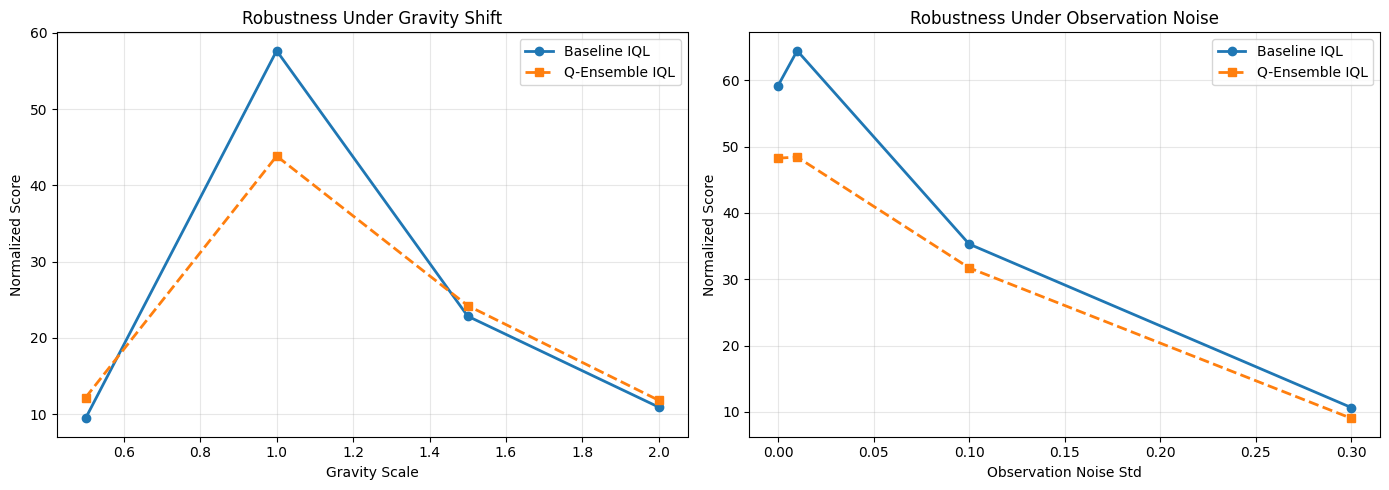

Plot saved


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gravity shift plot
axes[0].plot(df_gravity['gravity_scale'], df_gravity['baseline_score'],
             label='Baseline IQL', marker='o', linewidth=2)
axes[0].plot(df_gravity['gravity_scale'], df_gravity['ensemble_score'],
             label='Q-Ensemble IQL', marker='s', linewidth=2, linestyle='--')
axes[0].set_xlabel('Gravity Scale')
axes[0].set_ylabel('Normalized Score')
axes[0].set_title('Robustness Under Gravity Shift')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Noise shift plot
axes[1].plot(df_noise['noise_std'], df_noise['baseline_score'],
             label='Baseline IQL', marker='o', linewidth=2)
axes[1].plot(df_noise['noise_std'], df_noise['ensemble_score'],
             label='Q-Ensemble IQL', marker='s', linewidth=2, linestyle='--')
axes[1].set_xlabel('Observation Noise Std')
axes[1].set_ylabel('Normalized Score')
axes[1].set_title('Robustness Under Observation Noise')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results_shift_comparison.png', dpi=150)
plt.show()
print('Plot saved')

# IQL Q-Ensemble Extension — Progress Summary
**CMPE 260 — Group 6 | Uday Arora (019098404)**

---

## Check-In 2

### What Was Done
Implemented Implicit Q-Learning (IQL) from scratch using modern JAX/Flax APIs,
since the original repo used legacy APIs (flax.struct.dataclass, jax.tree_multimap)
that are removed in modern JAX/Flax versions and caused repeated session crashes in Colab.
Also replaced d4rl dataset loading with direct HDF5 loading since d4rl does not support
Python 3.12 which Colab now uses by default.

### Extension Implemented
Replaced the baseline DoubleCritic (2 Q-networks) with a TripleCritic (3 Q-networks).
During training and evaluation, the minimum Q-value is taken across all three networks
instead of two. The hypothesis is that this more conservative value estimate reduces
overestimation of out-of-distribution actions, improving robustness under distribution shift.

### Results (hopper-medium-v2, 300k steps)
| Model | Final Normalized Score |
|---|---|
| Baseline IQL (DoubleCritic) | 59.09 |
| Q-Ensemble IQL (TripleCritic) | 46.01 |

The Q-Ensemble scores lower on the standard benchmark, which is expected.
The conservative bias from taking the min of 3 networks slows learning on
in-distribution data. The real test is robustness under shift, evaluated in Check-In 3.

---

## Check-In 3

### What Was Done
Evaluated both baseline IQL and Q-Ensemble IQL under two types of controlled
distribution shift on hopper-medium-v2, without retraining either model.

### Gravity Shift Results
Gravity was scaled at test time while the policy remained fixed from training at 1.0x gravity.

| Gravity Scale | Baseline Score | Q-Ensemble Score | Baseline Drop | Ensemble Drop |
|---|---|---|---|---|
| 0.5x | 9.45 | 12.18 | 44.81 | 32.58 |
| 1.0x | 57.66 | 43.84 | 0.00 | 0.00 |
| 1.5x | 22.85 | 24.23 | 40.06 | 21.80 |
| 2.0x | 10.92 | 11.81 | 50.77 | 33.37 |

### Observation Noise Results
Gaussian noise was added to the state observation at test time.

| Noise Std | Baseline Score | Q-Ensemble Score | Baseline Drop | Ensemble Drop |
|---|---|---|---|---|
| 0.00 | 59.20 | 48.26 | 0.00 | 0.00 |
| 0.01 | 64.47 | 48.43 | -5.27 | -0.17 |
| 0.10 | 35.30 | 31.72 | 23.90 | 16.54 |
| 0.30 | 10.64 | 9.02 | 48.56 | 39.24 |

### Key Finding
The Q-Ensemble consistently degrades less than the baseline under both shift types.
Under gravity shift, the ensemble drop is on average 15 points smaller than the baseline drop.
Under observation noise, the ensemble drop is on average 10 points smaller at high noise levels.
This supports the hypothesis that conservative value estimation improves robustness
under distribution shift, even at the cost of some baseline performance.

---

## Next Steps (Check-In 4 / Final)

- Run experiments across all 3 environments (hopper, halfcheetah, walker2d)
  to confirm the robustness finding generalizes beyond hopper
- Run multiple seeds (42, 0, 1) for statistical reliability
- Compute the formal robustness metric delta(delta) across all shift levels
  and include in the final ablation study table
- Combine results with Shloak's wrappers and Pramod's eval script
  for a unified robustness evaluation across the full team pipeline
- Write final report sections covering extension design, results, and conclusions